# VPIN construction — Pass 1


In [1]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get('ARES_MICROSTRUCTURE') or (Path.home() / 'srv' / 'ares-microstructure')) / 'research' / 'books' / 'vpin_of'
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'

def jload(rel):
    p = OUT / rel
    return json.loads(p.read_text()) if p.is_file() else {}

def jlines(rel):
    p = OUT / rel
    if not p.is_file():
        return []
    return [json.loads(ln) for ln in p.read_text().splitlines() if ln.strip()]

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing* `{p}` — run `scripts/build_notebook_figs.py`'))

dec = jload('pass4/decisions_pass4.json') or jload('pass3/decisions_pass3.json') or jload('pass2/decisions_pass2.json') or jload('vpin_panel/decisions.json')
dec_promote = jload('vpin_panel/decisions_panel_promote.json')
rows = jlines('vpin_panel/rows.jsonl')
panel_ext = jload('pass2/panel_hl_db_extended.json')
ok_rows = panel_ext if isinstance(panel_ext, list) and panel_ext else [r for r in rows if r.get('ok')]
p4 = jload('pass4/pass4_summary.json')
p3 = jload('pass3/pass3_summary.json')
p2 = jload('pass2/pass2_summary.json')
tag = 'pass4' if p4 else ('pass3' if p3 else ('pass2' if p2 else 'pass1'))
print(tag, 'n_ok', dec.get('n_ok'), 'promote n_ok', dec_promote.get('n_ok'), 'counts', dec.get('decision_counts'), 'book', dec.get('book_status'))


pass4 n_ok 226 promote n_ok 139 counts {'Promote': 5, 'Hold': 6} book FINAL


**HL ETH 2026-09-30** complete=None n_trades=None bucket_vol=5.72 mean_vpin=0.9275288450534425 n_buckets=27382

,method,bucket_scale,bucket_volume,n_buckets,mean_vpin,p50_vpin,target_buckets
0,median_x_25,25.0,2.860000,37069,0.939004,0.950977,NaN
1,median_x_50,50.0,5.720000,27382,0.927529,0.938370,NaN
2,median_x_100,100.0,11.440000,18324,0.902497,0.913250,NaN
3,target_30_buckets,NaN,13372.998820,29,0.216184,0.216184,30.0
4,target_50_buckets,NaN,8023.799292,49,0.310745,0.310745,50.0
5,target_100_buckets,NaN,4011.899646,99,0.451835,0.457745,100.0


**Calibration grid** — `out/desk_synthesis/figs/fig_bucket_calibration.png`

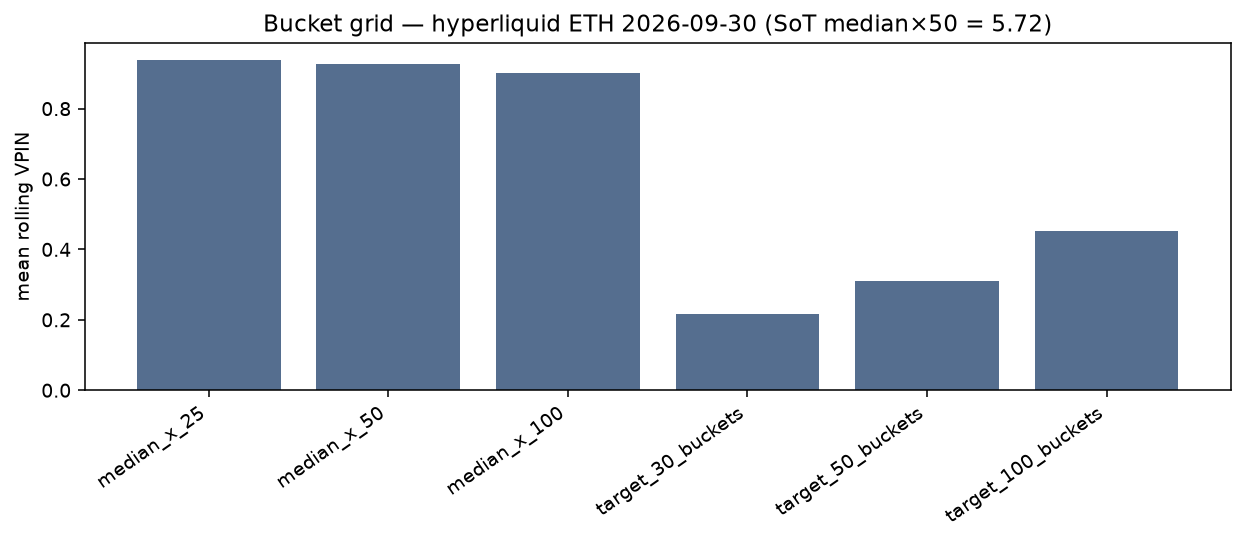

In [2]:
day = jload('vpin_day/hyperliquid_ETH_2026-09-30.json')
vs = day.get('vpin_summary') or day
display(Markdown(
    f"**HL ETH 2026-09-30** complete={day.get('complete')} "
    f"n_trades={day.get('n_trades')} bucket_vol={day.get('bucket_volume')} "
    f"mean_vpin={vs.get('mean_vpin')} n_buckets={vs.get('n_buckets')}"
))
cal = jload('vpin_panel/bucket_calibration.json')
display(pd.DataFrame(cal.get('grid', [])))
show_fig('fig_bucket_calibration.png', 'Calibration grid')
